# Image Processing Project
## Contour-Based Screw & Bolt Detection (Traditional Approach)
## Teaching Notebook


## 1. Industrial Problem Context
In manufacturing and inspection lines, engineers often need to count and classify mechanical components such as pcb, screws, bolts, or nuts from camera images.

Typical constraints:
    - Fixed camera position
    - Limited computation budget
    - Need for explainable decisions

In this notebook, we solve this problem using classical image processing (no machine learning).


## 2.Learning Objectives

By the end of this notebook, you should be able to:

- Understand a **complete classical image-processing pipeline**
- Use **edge detection and contours** to extract object shapes
- Compute **geometric features** from contours
- Design **rule-based classification logic**
- Recognize **failure cases** and limitations of classical methods

---

## 3. Overview of Image Detection
Image detection is the process of locating and classifying objects within images or video streams, typically by drawing bounding boxes around them. 

<img src="./images/ML_Tasks.jpg" width="750">


## 4. Processing Pipeline Overview

The overall processing pipeline is:

```
            Input Image
                 ↓
Preprocessing (Grayscale and Gaussian Blur)
                 ↓
        Feature Extraction 
(Edge Detection and Contour Extraction)
                 ↓
    Shape Feature (Aspect Ratio)
                 ↓
Rule-Based Classification (Screw vs Bolt) 
                 ↓ 
         Bounding Box Fitting
```

Each stage is **interpretable and tunable**, allowing us to adjust for changes on the factory floor (like new lighting or different component finishes).

**The Logic of Detection**

Unlike classification (identifying what is in an entire image), detection requires us to find the exact coordinates of each object. Our pipeline achieves this by converting raw pixels into geometric shapes that can be measured and labeled.

## 5 Part A: Preprocessing & Edge Detection

5.1 Reading and Preprocessing the image: 

Objective of our preprocessing is to reduces noises in the input images.

In a manufacturing environment, raw images contain "noise"—specular reflections from metal surfaces or sensor grain. To ensure our edge detector only finds the object's boundary.  

Since our features are edges and contours, we first apply :

    Grayscale Conversion: Reduces data complexity from three color channels (RGB) to one intensity channel.

and then 

    Gaussian Blur: Acts as a low-pass filter to smooth out pixel-level noise.

### 5.1 Import library


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 5.2 Load and Visualize Input Image

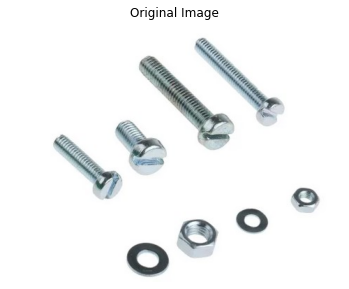

In [3]:
img = cv2.imread('images/screws.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

🔎 Observation:

    Objects have different shapes but similar color
    Lighting and background are relatively uniform
    
### 5.3 Preprocessing 

In [4]:
## Preprocessing
### 1 Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

### 2 Noise Reduction (Gaussian Blur)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

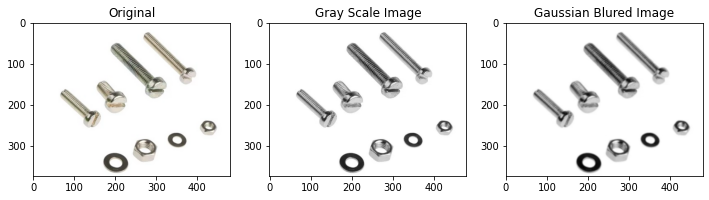

In [5]:
plt.figure(figsize=(12,12))
plt.subplot(131),plt.imshow(img),plt.title('Original')
plt.subplot(132),plt.imshow(gray, cmap='gray'),plt.title('Gray Scale Image')
plt.subplot(133),plt.imshow(blur, cmap='gray'),plt.title('Gaussian Blured Image')
plt.show()

### 5.4. Feature Extraction

### 5.4.1 Edge Detection

 Sudden changes of discontinuities in an image are called **EDGE**.
 
 Most of the shape information of an image is enclosed in edges. So first we detect these edges in an image using edge filters, later we can form the enclosed boundary of objects within images.
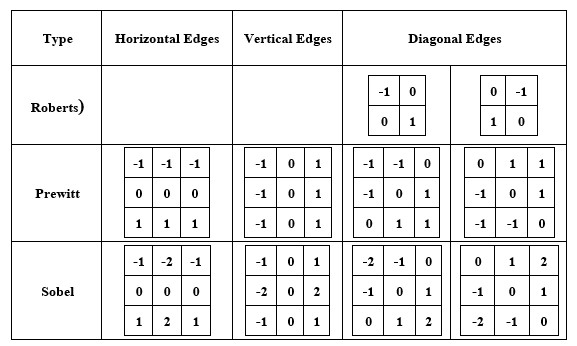

<div align="center">
    <img src="images/The-mathematical-explanation-of-the-convolution-operation_W640.jpg" width="400">
    <p style="text-align: center;">
        <i>Figure: Visualization of a convolution operation using an edge detection kernel.</i>
    </p>    
    <small>Source: <a href="https://www.researchgate.net/publication/334058390_Adapting_Laplacian_based_filtering_in_digital_image_processing_to_a_retina-inspired_analog_image_processing_circuit/figures?lo=1">Analog Integrated Circuits and Signal Processing (2019) 100:537–545</a>
    </small>
</div>


**Sobel Edge detection**

In [6]:
#Sobel Edge detector
sobelx = cv2.Sobel(blur,cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(blur,cv2.CV_64F,0,1,ksize=3)

#convert to 8 bits, we use 64 bits to handle negative value caused from white-to-black edge which has negative gradient
abs_sobel64f = np.absolute(sobelx)
sobelx = np.uint8(abs_sobel64f)
abs_sobel64f = np.absolute(sobely)
sobely = np.uint8(abs_sobel64f)

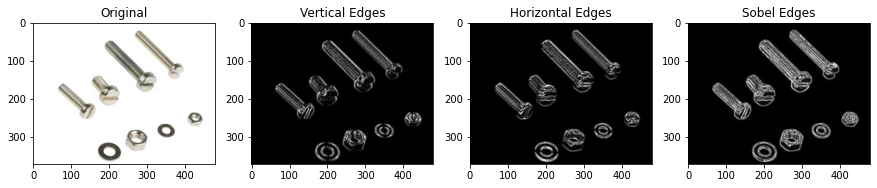

In [7]:
plt.figure(figsize=(15,15))
plt.subplot(141),plt.imshow(img,'gray'),plt.title('Original')
plt.subplot(142),plt.imshow(sobelx,'gray'),plt.title('Vertical Edges')
plt.subplot(143),plt.imshow(sobely,'gray'),plt.title('Horizontal Edges')
plt.subplot(144),plt.imshow(sobelx+sobely,'gray'),plt.title('Sobel Edges')
plt.show()

**From Simple Masks to Canny Edge Detection**

As discussed, we use convolution masks (like Sobel or Prewitt) to calculate the "gradient" or sudden changes in pixel intensity. However, raw edge filters often produce "thick" and "noisy" edges that are difficult for a computer to trace.

To solve this, we use the Canny Edge Detector, which is essentially a 3-step refinement process:

- Noise Reduction: It first applies a Gaussian blur mask to ensure that speckles of dust or sensor noise aren't mistaken for edges.

- Thinning (Non-Maximum Suppression): The algorithm looks at the gradient intensity and "thins" the edge down to a single pixel wide by keeping only the local maxima.

- **Hysteresis Thresholding**: Uses threshold1 (Low) and threshold2 (High). It keeps "strong" edges and includes "weak" edges only if they are connected to strong ones. This prevents edges from looking like "broken lines.
    
Why we use Canny Edges: It provides clean, thin, and continuous lines. This is the ideal input for contour Extraction, where we will "connect the dots" to form a shape.

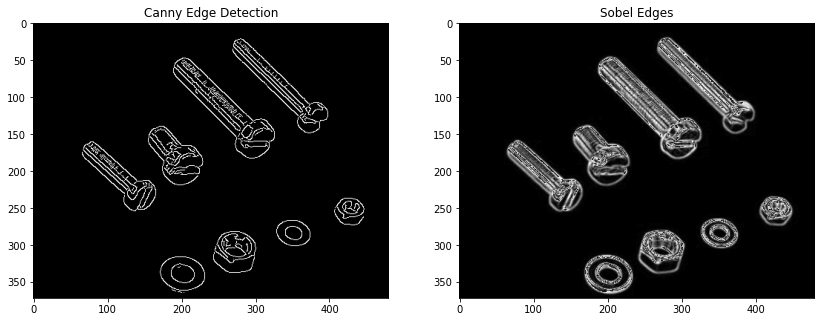

In [8]:
# Canny Edge Detection
edges = cv2.Canny(blur, threshold1=50, threshold2=150)

plt.figure(figsize=(14,14))
plt.axis('off')

plt.subplot(121)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detection')

plt.subplot(122)
plt.imshow(sobelx+sobely,'gray')
plt.title('Sobel Edges')

plt.show()

📌 Key insight:

    Edges represent shape information, which is critical for contour-based analysis.
    Threshold values required fine-tuned


## 5.4.2. Bridge to Geometry: Understanding findContours

At this stage, we have a binary image (from Canny Edge Detection) that shows us where the "interesting" pixels are. However, the computer still sees this as a flat grid of 0s and 1s. To classify a "Screw" vs. a "Bolt," we need to group these pixels into individual objects.

The Logic: OpenCV's findContours algorithm (Suzuki’s Algorithm) acts like a "Virtual Tracer." It scans the image until it hits a white pixel, then follows the boundary of that shape until it returns to the start.

Why this is critical for our pipeline:

    Pixels → Vectors: It converts raw pixel data into a structured list of (x,y) coordinates.

    Hierarchy: It can distinguish between an external boundary (the outline of a bolt) and an internal boundary (the hole in a nut).

    Feature Math: Once we have a contour, we can instantly calculate geometric properties like Area, Perimeter, and Centroid, which we will use for our classification rules.
   
<table style="width:60%; border:none;">
  <tr>
    <td style="text-align:center; border:none; width:50%;">
        <img src="images/canny_output.jpg" width="100%"><br>
        <small><b>Canny Edge Pixels</small>
    </td>
    <td style="text-align:center; border:none; width:50%;">
        <img src="images/contours_drawn.jpg" width="100%"><br>
        <small><b> Grouped Object Boundaries</small>
    </td>
  </tr>
</table>

OpenCV Function: 
    
contours, hierarchy = **cv2.findContours**(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

This function requires a binary image in which an object is 1 and background is '0'.

Engineering Tip: We often use RETR_EXTERNAL in the code below. This tells OpenCV to ignore internal "holes" (noise) and only give us the outer silhouettes of our components, simplifying our classification task.

Key Steps for Contour Detection:

    Convert an image to gray scale image
    Apply Threshold/Canny to convert gray scale image to a binary image
    Pass the binary image to cv2.findContours

📌 Each contour represents a candidate object boundary.

**Apply Thresholding**

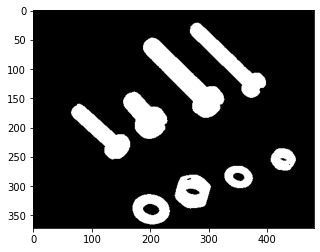

In [9]:
# Pixels with intensity > 240 become 0 (black)
# Pixels with intensity <= 240 become 255 (white)
threshold_value = 240
max_value = 255

ret, thresh_inv = cv2.threshold(blur, threshold_value, max_value, cv2.THRESH_BINARY_INV)

plt.imshow(thresh_inv,'gray')

**Find Contours**

In [10]:
#imt, contours, hierarchy = cv2.findContours(thresh_inv, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
imt, contours, hierarchy = cv2.findContours(thresh_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Number of detected contours: {len(contours)}")

Number of detected contours: 8


## 5.5 From Shapes to Detection: Logic & Localization

Once we have the contours, we transform these geometric points into actionable data through Feature Extraction and Rule-Based Classification. 


| Feature | Condition | Resulting Label |
| :--- | :--- | :--- |
| **Aspect Ratio** | > 1.4 | 🔩 **Screw** (Long & Thin) |
| **Aspect Ratio** | <= 1.4 | ⚙️ **Bolt Head** (Square/Circular) |
| **Area** | < 500 pixels | ❌ **Noise** (Ignore) |

We calculate the Aspect Ratio (Width / Height) for each contour. 

- Screws are typically elongated (Will have a high ratio)
- Bolts/nuts are more compact (The ratio stays close to 1.0.)

Based on these ratios, we apply a Classification Rule—a simple "If-Then" logic—to assign a label to the object. 

Finally, to complete the Detection task, we fit a Bounding Box (a cvRect) around the identified contour. 

This allows us to localize the object in the image and draw a visual box with the label, transforming raw mathematical features into a detection output.

**Rule-based Classification**

In [12]:
# Rule-based Classification
font = cv2.FONT_HERSHEY_SIMPLEX
screw_count = 0
bolt_count = 0

output = img.copy()

for contour in contours:
    
    area = cv2.contourArea(contour)  # Compute the area of the shape

    if area < 500:     # Ignore small regions
        continue
        
    #Get rotated rectangular bounding box dimensions
    rect = cv2.minAreaRect(contour)
    (x_c, y_c), (w, h), angle = rect

    #Calculate Aspect Ratio (ensure we don't divide by zero)
    if w == 0 or h == 0:
        continue

    aspect_ratio = max(w, h) / min(w, h)

    #Classify based on shape
    if aspect_ratio > 1.4:
        label = 'Screw'
        color = (255, 0, 0)
        screw_count += 1
    else:
        label = 'Bolt / Nut'
        color = (0, 0, 255)
        bolt_count += 1
            
    # Draw Rotated Box
    box = cv2.boxPoints(rect)
    box = np.int0(box)
    cv2.drawContours(output, [box], 0, color, 2)
    cv2.putText(output, label, (int(x_c), int(y_c)), font, 0.5, color, 2)

**Visualize Final Results**

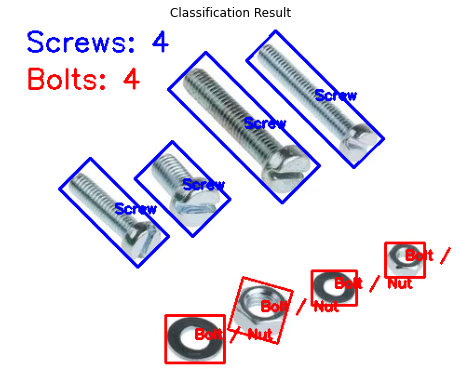

In [13]:
cv2.putText(output, f'Screws: {screw_count}', (20, 30), font, 1, (255, 0, 0), 2)
cv2.putText(output, f'Bolts: {bolt_count}', (20, 70), font, 1, (0, 0, 255), 2)

output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(output_rgb)
plt.title('Classification Result')
plt.axis('off')
plt.show()

## 6. Discussion: Why This Works

✔ Simple geometry
✔ Strong shape differences
✔ Controlled imaging conditions
✔ Fast and explainable

This approach is widely used in **real production lines**.

---

## 7. Failure Cases and Limitations

❌ Overlapping objects
❌ Unusual orientations
❌ Lighting changes
❌ Different screw types

📌 Rule-based systems **do not generalize well**.

---

## 8. Transition to Learning-Based Methods

**Question:**
> What if shape rules are not enough?

This motivates the next project:

➡ **Defect classification using CNNs**

---

## 9. Key Takeaways

- Classical image processing is powerful and interpretable
- Feature engineering is manual and brittle
- Rules must be redesigned when conditions change
- CNNs trade explainability for robustness

Readings: 

Image Convolution: 
https://share.google/SJROfmUjfIYJApWeh

https://opencv.org/blog/image-filtering-using-convolution-in-opencv/

Edge Detection Theory: 
https://github.com/bockp/Edge-Detection-project/blob/master/edge.md

References:
- https://docs.opencv.org/3.4/df/d0d/tutorial_find_contours.html